In [1]:
from torch.utils.data import Dataset
import torch
import os
import glob
import cv2
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset, Subset, ConcatDataset
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from models.HITEC import Model
import pickle
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import re
import sklearn.metrics
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib import colormaps
import cv2
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image, ImageDraw, ImageFont
import sys
from utils import *

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

with open('utils/tokenizer.pickle', 'rb') as f :
    tokenizer = pickle.load(f)
with open('utils/output_classes.pkl', 'rb') as f :
    le = pickle.load(f)

In [2]:
# HIT-EC
def avg_heads(cam, grad):
    cam = cam.reshape(-1, cam.shape[-2], cam.shape[-1])
    grad = grad.reshape(-1, grad.shape[-2], grad.shape[-1])
    cam = grad * cam
    cam = cam.clamp(min=0).mean(dim=0)
    return cam

def apply_self_attention_rules(R_ss, cam_ss):
    R_ss_addition = torch.matmul(cam_ss, R_ss)
    return R_ss_addition

def generate_relevance(sequence, model, level_sizes=[len(le[0]), len(le[1]), len(le[2]), len(le[3])], labels=None, target_ec=None, force_chain=True, max_len=1024, bos_id=22):
    with open('utils/tokenizer.pickle', 'rb') as f :
        tokenizer = pickle.load(f)
    seq = tokenizer.texts_to_sequences([sequence])
    seq[0] = [bos_id] + seq[0]
    seq[0] += [0 for _ in range(max_len - len(seq[0]))]
    device = next(model.parameters()).device if any(True for _ in model.parameters()) else torch.device("cpu")
    seq = torch.tensor(seq, dtype=torch.int32, device=device)

    starts = [0]
    for s in level_sizes[:-1]:
        starts.append(starts[-1] + s)

    def rollout(global_idx):
        model.eval()
        out_inter = model(seq, mode='inter')
        one_hot = torch.zeros((1, out_inter.size(-1)), dtype=torch.float32, device=out_inter.device)
        one_hot[0, global_idx] = 100.0
        t = torch.sum(one_hot * out_inter)
        model.zero_grad()
        t.backward()
        R = torch.eye(max_len, max_len, device=out_inter.device)
        for blk in [model.model.enc_1, model.model.enc_2, model.model.enc_3, model.model.enc_4]:
            cam = blk.inter_attention.get_attn()
            grad = blk.inter_attention.get_attn_gradients()
            cam = avg_heads(cam, grad)
            R = R + apply_self_attention_rules(R, cam)
        return R[0,1:]

    def global_from_level(i_level, local_idx):
        return starts[i_level] + local_idx

    if target_ec is not None:
        if labels is None:
            raise ValueError("labels (per-level or flat) required to locate target_ec")
        if force_chain and isinstance(labels[0], (list, tuple)):
            parts = str(target_ec).split(".")
            chain = []
            if len(parts) >= 1: chain.append(parts[0])
            if len(parts) >= 2: chain.append(".".join(parts[:2]))
            if len(parts) >= 3: chain.append(".".join(parts[:3]))
            if len(parts) >= 4: chain.append(".".join(parts[:4]))
            targets = []
            for i, ec_str in enumerate(chain):
                try:
                    li = labels[i].index(ec_str)
                    gi = global_from_level(i, li)
                    targets.append(gi)
                    print(f"Forced L{i+1}: {ec_str} | gidx={gi}")
                except ValueError:
                    print(f"Forced L{i+1}: {ec_str} not found, skipping")
            if not targets:
                raise ValueError("No levels found for target_ec in labels")
            Rs = [rollout(gi) for gi in targets]
            return torch.stack(Rs, dim=0).mean(dim=0)
        else:
            if isinstance(labels[0], (list, tuple)):
                off = 0
                gi = None
                for i, lab in enumerate(labels):
                    try:
                        li = lab.index(target_ec)
                        gi = off + li
                        break
                    except ValueError:
                        off += level_sizes[i]
                if gi is None:
                    raise ValueError("target_ec not found in labels")
            else:
                try:
                    gi = int(labels.index(target_ec))
                except ValueError:
                    raise ValueError("target_ec not found in labels")
            print(f"Forced EC: {target_ec} | gidx={gi}")
            return rollout(gi)

    model.eval()
    out_infer = model(seq, mode='infer')
    out_infer = out_infer['final_logit']

    
    Rs = []
    for i in range(4):
        s, e = starts[i], starts[i] + level_sizes[i]
        logits = out_infer[0, s:e]
        li = int(torch.argmax(torch.sigmoid(logits)).item())
        gi = s + li
        sc = float(torch.max(torch.sigmoid(logits)).item())
        if labels is not None:
            try:
                lbl = labels[i][li] if isinstance(labels[0], (list,tuple)) else labels[gi]
            except Exception:
                lbl = f"idx{li}"
            print(f"L{i+1}: {lbl} | score={sc:.6f} | gidx={gi}")
        else:
            print(f"L{i+1}: idx={li} | score={sc:.6f} | gidx={gi}")
        Rs.append(rollout(gi))
        
    thresh=0.4
    s4, e4 = starts[3], starts[3] + level_sizes[3]
    logits_l4 = out_infer[0, s4:e4]
    probs_l4 = torch.sigmoid(logits_l4)  
    idxs = (probs_l4 > thresh).nonzero(as_tuple=False).flatten().tolist()
    if idxs:
        cands = sorted(((li, float(probs_l4[li].item())) for li in idxs), key=lambda x: -x[1])
        print(f"--- L4 candidates with score > {thresh} ---")
        for li, sc in cands:
            gi = s4 + li
            if labels is not None:
                try:
                    lbl = labels[3][li] if isinstance(labels[0], (list, tuple)) else labels[gi]
                except Exception:
                    lbl = f"idx{li}"
            else:
                lbl = f"idx{li}"
            print(f"L4 candidate: {lbl} | score={sc:.6f} | gidx={gi}")
            
    return torch.stack(Rs, dim=0).mean(dim=0)

def plot(y_pred, color):
    img = np.zeros((20, 20, 3), dtype=np.uint8)

    img[0:20, 0:20] = color[::-1]

    return img


def plotting_alpha(value, text, color):
    img = plot(value, color)
    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = 0.7
    text = "%s" % text

    cv2.putText(img, text, (1, len(img) - 2), font, scale, (10, 10, 10), 1)


    return img

def read_and_sort_fasta(file_path):
    fasta_list = []
    with open(file_path, 'r') as f:
        current_id = None
        current_seq = []
        
        for line in f:
            line = line.strip()
            if not line: continue
            
            if line.startswith('>'):
                if current_id is not None:
                    seq_id_num = int(re.sub(r'[^0-9]', '', current_id))
                    fasta_list.append((seq_id_num, "".join(current_seq)))
                current_id = line
                current_seq = []
            else:
                current_seq.append(line)
        
        if current_id is not None:
            seq_id_num = int(re.sub(r'[^0-9]', '', current_id))
            fasta_list.append((seq_id_num, "".join(current_seq)))

    fasta_list.sort(key=lambda x: x[0])
    
    sorted_sequences = [item[1] for item in fasta_list]
    
    sorted_ids = [item[0] for item in fasta_list]
    print(f"Sorted order: {sorted_ids}")
    
    return sorted_sequences

In [3]:
# ECPICK
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data

class SequenceDataset(torch.utils.data.Dataset):
    def __init__(self, y_true, y_true_one_hot, x_value):
        self.y_true = y_true
        self.y_true_one_hot = y_true_one_hot
        self.x_value = x_value

    def __len__(self):
        return len(self.y_true)

    def __getitem__(self, index):
        return self.y_true_one_hot[index], self.x_value[index]

class Interpretation:

    def __init__(self, feature_map):
        self.feature_map = feature_map

    @staticmethod
    def __relu(array):
        array[array < 0] = 0
        return array

    @staticmethod
    def __prepend_zero(arr):
        return np.concatenate((np.array([0]), arr[:-1]))

    @staticmethod
    def __alpha(mbr, max_prob):
        return np.gradient(mbr + sys.float_info.epsilon, 1 / max_prob[0])

    def __get_beta(self, mbr, cfr, max_prob):
        alpha = self.__relu(self.__alpha(mbr, max_prob))
        sorted_index = np.argsort(alpha)[::-1]
        result = None

        for i in range(self.feature_map):
            result = (result + cfr[sorted_index[i]]) if result is not None else cfr[sorted_index[i]]

        return self.__relu(result)

    def final_beta(self, mbr1, mbr2, mbr3, cfr1, cfr2, cfr3, max_prob):
        result1 = self.__get_beta(mbr1, cfr1, max_prob)
        result2 = self.__get_beta(mbr2, cfr2, max_prob)
        result3 = self.__get_beta(mbr3, cfr3, max_prob)

        result2 = np.append(result2, np.zeros(len(result1) - len(result2)))
        result3 = np.append(result3, np.zeros(len(result1) - len(result3)))

        return result1 + result2 + result3

    def individual_beta(self, mbr, cfr, max_prob, channel):
        beta = self.__get_beta(mbr, cfr, max_prob)
        result = None

        for i in range(channel):
            conv_beta = self.__prepend_zero(beta)
            result = (result + conv_beta) if result is not None else conv_beta
            beta = conv_beta

        return result

class PredictDataset(torch.utils.data.Dataset):
    def __init__(self, x_value):
        self.x_value = x_value

    def __len__(self):
        return len(self.x_value)

    def __getitem__(self, index):
        return self.x_value[index]

class Flatten(nn.Module):
    def __init__(self):
        super(Flatten, self).__init__()

    def forward(self, x):
        return x.view(x.size(0), -1)

class SeqEncoder:
    def __init__(self):
        self.categories = np.array(list('ACDEFGHIKLMNPQRSTVWYX'))

    def char_to_one_hot_encoding(self, c):
        X_int = np.zeros(len(self.categories), dtype=np.int8)
        index = np.where(self.categories == c)[0]

        if len(index) == 0: return X_int

        X_int[index] = 1
        return X_int

    def seq_to_one_hot_encoding(self, seq):
        return np.array([self.char_to_one_hot_encoding(c) for c in seq])

    def one_hot_encoding_to_seq(self, one_hot_encoding):
        X = np.array(one_hot_encoding).reshape(-1, 21)
        last_index = np.where(np.sum(X, axis=1) == 0)[0]
        last_index = 1000 if len(last_index) == 0 else last_index[0]
        return ''.join(self.categories[X.argmax(axis=1)][:last_index])

In [4]:
from models.CLEAN import LayerNormNet

def csv_to_fasta(csv_name, fasta_name):
    csvfile = open(csv_name, 'r',encoding='utf-8')
    csvreader = csv.reader(csvfile, delimiter='\t')
    outfile = open(fasta_name, 'w',encoding='utf-8')
    for i, rows in enumerate(csvreader):
        if any(char.isdigit() for char in rows[2]):
            continue
        if i > 0:
            outfile.write('>' + rows[0] + '\n')
            outfile.write(rows[2] + '\n')
    
def infer_maxsep(train_data, test_data, report_metrics = False, 
                 pretrained=True, model_name=None, gmm = None, date=None):
    with open('utils/output_classes.pkl', 'rb') as f :
        le = pickle.load(f)
    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda:0" if use_cuda else "cpu")
    dtype = torch.float32
    id_ec_train, ec_id_dict_train = get_ec_id_dict(train_data + '.csv')
    id_ec_test, _ = get_ec_id_dict(test_data + '.csv')
    ec_to_idx_map = {ec: i for i, ec in enumerate(le[3])}
    
    # load checkpoints
    # NOTE: change this to LayerNormNet(512, 256, device, dtype) 
    # and rebuild with [python build.py install]
    # if inferencing on model trained with supconH loss
    model = LayerNormNet(512, 256, device, dtype)
    
    if pretrained:
        try:
            checkpoint = torch.load('./data/pretrained/'+ train_data +'.pth', map_location=device)
        except FileNotFoundError as error:
            raise Exception('No pretrained weights for this training data')
    else:
        try:
            checkpoint = torch.load(model_name +'.pth', map_location=device)
        except FileNotFoundError as error:
            raise Exception('No model found!')
            
    model.load_state_dict(checkpoint)
    model.eval()
    # load precomputed EC cluster center embeddings if possible
    if train_data == "split70":
        emb_train = torch.load('./data/pretrained/70.pt', map_location=device)
    elif train_data == "split100":
        emb_train = torch.load('./data/pretrained/100.pt', map_location=device)
    else:
        emb_train = torch.load(f'base_learners/CLEAN_models/STACKING_train_esm_embedding_cache.pt', map_location=device)

    emb_test = model_embedding_test(id_ec_test, model, device, dtype)
    eval_dist = get_dist_map_test(emb_train, emb_test, ec_id_dict_train, id_ec_test, device, dtype)
    seed_everything()
    eval_df = pd.DataFrame.from_dict(eval_dist)
    out_filename = test_data

    write_max_sep_choices(eval_df, out_filename, gmm=gmm)
    if report_metrics:
        pred_label = get_pred_labels(out_filename, pred_type='_maxsep', date=date)
        pred_probs = get_pred_probs(out_filename, pred_type='_maxsep', date=date)
        true_label, all_label = get_true_labels('./data/' + test_data)
        pre, rec, f1, roc, acc = get_eval_metrics(
            pred_label, pred_probs, true_label, all_label)
        print("############ EC calling results using maximum separation ############")
        print('-' * 75)
        print(f'>>> total samples: {len(true_label)} | total ec: {len(all_label)} \n'
            f'>>> precision: {pre:.3} | recall: {rec:.3}'
            f'| F1: {f1:.3} | AUC: {roc:.3} ')
        print('-' * 75)
    else:
        pred_label = get_pred_labels(out_filename, pred_type='_maxsep', date=date)
        pred_probs = get_pred_probs(out_filename, pred_type='_maxsep')

    print("\n--- CLEAN Prediction Result ---")
    for label in pred_label:
        print(f"Label: {label}")
    for prob in pred_probs:
        print(f"Probbabilities: {float(prob)}")

    clean_outputs = create_soft_label_tensor(pred_label, pred_probs, ec_to_idx_map, len(le[3]), device, dtype)
    return emb_test, clean_outputs

In [5]:
# IDF-EC INFERENCE

import csv
from models.HITEC import Model
from models.ECPICK import PredictionModel
from models.IDFEC import IDF_EC
from utils.utils import *

def IDF_EC_INFERENCE(sequence, interpretation=False):
    #-------------------------------------------- ECPICK --------------------------------------------#
    ##### ECPICK MODEL LOAD #####
    cuda_available = torch.cuda.is_available()
    if cuda_available:
        print(f"-##### CUDA is available #####-")
        device = torch.cuda.current_device()
    else:
        print(f"-##### CUDA is not available #####-")
        device = torch.device('cpu')
        
    model_path = glob.glob(os.path.join(f"base_learners/ECPICK_models", '*.pth'))
    ecpick_models = []
    
    for i in range(len(model_path)):
        ecpick_model = PredictionModel(output_classes=le, cuda_support=cuda_available, cuda_device=device, dropout_rate=0.8,
                                relu_size=384, beta=0.6, model_path=model_path[i])
        ecpick_model = ecpick_model.to(device)
        ecpick_model.eval()
        ecpick_models.append(ecpick_model)
    
    ##### ECPICK INPUT SEQUENCE ENCODING ##### 
    seqencoder = SeqEncoder()
    if len(sequence) > 1000:
        ecpick_sequence = sequence[:1000]
    else:
        ecpick_sequence = sequence
    ecpick_sequence = ecpick_sequence + (' ' * (1000 - len(ecpick_sequence)))
    ecpick_sequence = seqencoder.seq_to_one_hot_encoding(ecpick_sequence)
    x_value = np.reshape(np.array([ecpick_sequence]), (len([ecpick_sequence]), 1, 1000, 21))
    x_value = torch.tensor(x_value).to(device).float()
    
    ##### ECPICK OUTPUT ######
    ecpick_features = []
    ecpick_outputs = []
    with torch.no_grad():
        for ecpick_model in ecpick_models:
            ecpick_result = ecpick_model(x_value)
            ecpick_features.append(ecpick_result['feature_vector'])
            ecpick_outputs.append(ecpick_result['final_output'])
    ecpick_stacked_outputs = torch.stack(ecpick_outputs, dim=0)   
    ecpick_mean_outputs = ecpick_stacked_outputs.mean(dim=0) 
    ecpick_stacked_features = torch.stack(ecpick_features, dim=0) 
    ecpick_mean_feature = ecpick_stacked_features.mean(dim=0)
    
    above_threshold_args = [i for i in range(len(ecpick_mean_outputs[0])) if ecpick_mean_outputs[0][i] > 0.19]
    print("\n--- ECPICK Prediction Result ---")
    for label in above_threshold_args:
        print(f"Label: {le[3][label]} | Probability: {ecpick_mean_outputs[0][label]:.4f}")
    
    #-------------------------------------------- HIT-EC --------------------------------------------#
    ##### HIT-EC MODEL LOAD #####
    model_path = f'base_learners/HIT-EC_models/hitec.ckpt'
    config = {
        'ah': 2,
        'dr': 0.1,
        'beta': 0.59,
        'output_dims': [len(le[0]), len(le[1]), len(le[2]), len(le[3])]
    }
    hitec_model = Model(config)
    model_data = torch.load(model_path, map_location=torch.device('cpu'), weights_only=False)
    hitec_model.load_state_dict(model_data['state_dict'])
    hitec_model.eval()
    
    ##### HIT-EC INPUT SEQUENCE ENCODING ##### 
    hitec_sequence = tokenizer.texts_to_sequences([sequence[:1023]])
    hitec_sequence[0] = [22] + hitec_sequence[0]
    hitec_sequence[0] += [0 for _ in range(1024-len(hitec_sequence[0]))]
    hitec_sequence = torch.Tensor(hitec_sequence).int()
    
    ##### HIT-EC OUTPUT ######
    with torch.no_grad():
        hitec_result = (hitec_model(hitec_sequence, mode='infer'))
        hitec_features = hitec_result['feature_vectors']
        hitec_outputs = hitec_result['final']
        hitec_outputs = (hitec_outputs[:, -(len(le[3])):])
    
    above_threshold_args = [i for i in range(len(hitec_outputs[0])) if hitec_outputs[0][i] > 0.4]
    print("\n--- HIT-EC Prediction Result ---")
    for label in above_threshold_args:
        print(f"Label: {le[3][label]} | Probability: {torch.sigmoid(hitec_outputs[0][label]):.4f}")
    print()
    
    
    #-------------------------------------------- CLEAN --------------------------------------------#
    train_data = 'data/CLEAN/train_clean_final'
    test_data = "inter_inference"
    
    with open(f'clean_inference/{test_data}.csv', 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f, delimiter='\t')
        writer.writerow(["Entry", "EC number", "Sequence"])
        writer.writerow(["inference", "_", sequence])
    
    csv_to_fasta(f'clean_inference/{test_data}.csv', f'clean_inference/{test_data}.fasta')
    prepare_infer_fasta(test_data)
    clean_features, clean_outputs = infer_maxsep(train_data, f'clean_inference/{test_data}', report_metrics=False, pretrained=False, model_name='base_learners/CLEAN_models/clean')
    #-------------------------------------------- IDF-EC --------------------------------------------#
    ecpick_mean_feature = ecpick_mean_feature.to(device)
    ecpick_mean_outputs = ecpick_mean_outputs.to(device)
    hitec_features = [f.to(device) for f in hitec_features]
    hitec_outputs = hitec_outputs.to(device)
    clean_features = clean_features.to(device)
    clean_outputs = clean_outputs.to(device)
    
    
    stacking_model = IDF_EC(
        output_classes=le,
        cuda_available=cuda_available,
        device=device,
        num_classes=len(le[3]),
        ecpick_feature=384,
        hitec_feature=1024,
        clean_feature=256
    ).to(device)
    checkpoint_path = f'saved_models/final_epoch=5.pth'
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cuda', device))
    stacking_model.load_state_dict(checkpoint, strict=False)
    
    stacking_output, _, w_ec, w_hi, w_ci = stacking_model(
        ecpick_mean_feature, 
        ecpick_mean_outputs, 
        hitec_features, 
        hitec_outputs,
        clean_features,
        clean_outputs,
        gate=True
    )
    
    outputs = (torch.sigmoid(stacking_output))
    above_threshold_args = [i for i in range(len(outputs[0])) if outputs[0][i] > 0.22]
    threshold_probs = outputs[0][above_threshold_args]
    threshold_labels = le[3][above_threshold_args]
    
    print("\n--- IDF-EC Prediction Result ---")
    for label, prob in zip(threshold_labels, threshold_probs):
        print(f"Label: {label} | Probability: {prob.item():.4f}")

    if interpretation==True:
        print(f"w_ec : {w_ec} | w_hi : {w_hi}")
        return w_ec, w_hi, w_cl
    else:
        return None, None, None

In [6]:
# Input your own sequence
sequences = [
    'MTTSASSHLNKGIKQVYMSLPQGEKVQAMYIWIDGTGEGLRCKTRTLDSEPKCVEELPEWNFDGSSTLQSEGSNSDMYLVPAAMFRDPFRKDPNKLVLCEVFKYNRRPAETNLRHTCKRIMDMVSNQHPWFGMEQEYTLMGTDGHPFGWPSNGFPGPQGPYYCGVGADRAYGRDIVEAHYRACLYAGVKIAGTNAEVMPAQWEFQIGPCEGISMGDHLWVARFILHRVCEDFGVIATFDPKPIPGNWNGAGCHTNFSTKAMREENGLKYIEEAIEKLSKRHQYHIRAYDPKGGLDNARRLTGFHETSNINDFSAGVANRSASIRIPRTVGQEKKGYFEDRRPSANCDPFSVTEALIRTCLLNETGDEPFQYKN'
]

for sequence in sequences:
    w_ec, w_hi, w_cl = IDF_EC_INFERENCE(sequence, interpretation=False)

-##### CUDA is available #####-

--- ECPICK Prediction Result ---
Label: 2.3.1.225 | Probability: 0.5240
Label: 6.3.1.2 | Probability: 0.5929

--- HIT-EC Prediction Result ---
Label: 2.3.1.225 | Probability: 0.7311
Label: 6.3.1.2 | Probability: 0.7311

Transferred model to GPU
Read clean_inference/inter_inference.fasta with 1 sequences
Processing 1 of 1 batches (1 sequences)

--- CLEAN Prediction Result ---
Label: ['6.3.1.2']
Probbabilities: 1.0

--- IDF-EC Prediction Result ---
Label: 2.3.1.225 | Probability: 0.9655
Label: 6.3.1.2 | Probability: 1.0000


/home/jeons9/nas/IDF-EC/github/models/IDFEC.py:71: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  f"{name}_std":  t.std().item(),


In [7]:
from models.ECPICK import InterpretationModel

def IDR_inter(sequences):
    with open('utils/tokenizer.pickle', 'rb') as f :
        tokenizer = pickle.load(f)
    with open('utils/output_classes.pkl', 'rb') as f :
        le = pickle.load(f)
    # aligned_sequences = read_and_sort_fasta('./hitec_inter_imgs/ec7.txt')
    
    # HIT-EC LOAD
    model_path = f'base_learners/HIT-EC_models/hitec.ckpt'
    config = {
        'ah': 2,
        'dr': 0.1,
        'beta': 0.59,
        'output_dims': [len(le[0]), len(le[1]), len(le[2]), len(le[3])]
    }
    
    hitec_model = Model(config)
    model_data = torch.load(model_path, map_location=torch.device('cpu'), weights_only=False)
    hitec_model.load_state_dict(model_data['state_dict'])
    hitec_model.eval()
    csv_path= './hitec_inter_imgs/'

    # ECPICK LOAD
    seq_encoder = SeqEncoder()
    cuda_available = torch.cuda.is_available()
    if cuda_available:
        cuda_device = torch.cuda.current_device()
    model_path = glob.glob(os.path.join(f"base_learners/ECPICK_models", '*.pth'))
    ecpick_models = []
    result_p = []
    for i in range(len(model_path)):
        model = InterpretationModel(output_classes=le, cuda_support=cuda_available, cuda_device=cuda_device, dropout_rate=0.8,
                                relu_size=384, beta=0.6, model_path=model_path[i])
        model.eval()
        model.register_hook()
        ecpick_models.append(model)

    num_of_class = len(le[-1])
    
    for i, sequence in enumerate(sequences):
        w_ec, w_hi, w_cl = IDF_EC_INFERENCE(sequence, interpretation=True)
        
        r_img = np.zeros((20, 20 * len(sequence), 3))
    
        exp = generate_relevance(sequence, hitec_model).detach()
        kernel_size = 6
        kernel = np.ones(kernel_size) / kernel_size
        exp = np.convolve(exp, kernel, mode='same')
    
        exp = exp - exp.min()
        exp = exp / exp.max()

        hitec_value = []
        char_index = 0
        for j in range(len(sequence)):
            if sequence[j] == "-":
                hitec_value.append((0, sequence[j]))
            else:
                hitec_value.append((exp[char_index], sequence[j]))
                char_index = char_index + 1
        hitec_value = np.array(hitec_value)

        ecpick_sequences = []


        processed_seq = sequence
        if len(processed_seq) > 1000: 
            processed_seq = processed_seq[:1000]
        processed_seq = processed_seq + (' ' * (1000 - len(processed_seq)))

        one_hot_seq = seq_encoder.seq_to_one_hot_encoding(processed_seq)
        X_single = torch.tensor(one_hot_seq).unsqueeze(0).unsqueeze(0).float() # (1, 1, 1000, 21)
        if cuda_available:
            X_value = X_single.to(cuda_device)
        
        result_prob = None
        result_int_1 = None
        result_int_2 = None
        result_int_3 = None
        sample_len = X_value.shape[0]

        for model_num in range(len(ecpick_models)):
            outputs_p = ecpick_models[model_num](X_value)['final_output']
            result_prob = (result_prob + outputs_p) if result_prob is not None else outputs_p
        result_prob /= len(ecpick_models)
        result_p.append(result_prob.tolist())
        max_prob_arg = np.array(torch.argmax(result_prob, dim=1, keepdim=True).tolist()).reshape(-1)[0]
        above_threshold_args = [i for i in range(len(result_prob[0].tolist())) if result_prob[0].tolist()[i] > .19]

        for model_num in range(len(ecpick_models)):
            outputs_p = ecpick_models[model_num](X_value)['final_output']
            outs = outputs_p.squeeze()
            outs[max_prob_arg].backward(retain_graph=True)
    
            # compute interpretation
            mbr_1 = ecpick_models[model_num].max_pool_1_backward_result.detach().cpu().numpy()
            mbr_2 = ecpick_models[model_num].max_pool_2_backward_result.detach().cpu().numpy()
            mbr_3 = ecpick_models[model_num].max_pool_3_backward_result.detach().cpu().numpy()
    
            cfr_1 = ecpick_models[model_num].cnn_1_forward_result.detach().cpu().numpy()
            cfr_2 = ecpick_models[model_num].cnn_2_forward_result.detach().cpu().numpy()
            cfr_3 = ecpick_models[model_num].cnn_3_forward_result.detach().cpu().numpy()
    
            max_prob = torch.max(outputs_p, dim=1, keepdim=True)[0].detach().cpu().numpy().reshape(sample_len)
            interpretation = Interpretation(40) 
            
            # Level 2 Interpretation
            individual_beta_c1 = interpretation.individual_beta(mbr_1, cfr_1, max_prob, 4)
            individual_beta_c2 = interpretation.individual_beta(mbr_2, cfr_2, max_prob, 8)
            individual_beta_c2 = np.append(individual_beta_c2, np.zeros(len(cfr_1[0]) - len(cfr_2[0])))
            individual_beta_c3 = interpretation.individual_beta(mbr_3, cfr_3, max_prob, 16)
            individual_beta_c3 = np.append(individual_beta_c3, np.zeros(len(cfr_1[0]) - len(cfr_3[0])))
            individual_beta = individual_beta_c1 + individual_beta_c2 + individual_beta_c3
            result_int_2 = (result_int_2 + individual_beta) if result_int_2 is not None else individual_beta

        max_prob_arg = np.array(torch.argmax(result_prob, dim=1, keepdim=True).tolist()).reshape(-1)
        above_threshold_args = [i for i in range(len(result_prob[0].tolist())) if result_prob[0].tolist()[i] > .19]
        
        ecpick_value = []
        char_index = 0
        for k in range(len(sequence)):
            if sequence[k] == "-":
                ecpick_value.append((0, sequence[k]))
            else:
                ecpick_value.append((result_int_2[char_index], sequence[k]))
                char_index = char_index + 1
    
        csv_path = f"demo_interpretation/ecpick"

        ecpick_value = np.array(ecpick_value)

        df = pd.DataFrame(ecpick_value, columns=["value", 'seq'])
        df.to_csv(f"{csv_path}/{i}.csv")

        
        ecpick_value = ecpick_value[:, 0].astype(float)

        ec_scores_min = ecpick_value.min()
        ec_scores_max = ecpick_value.max()
        
        ecpick_value = (ecpick_value - ec_scores_min) / (ec_scores_max - ec_scores_min + 1e-8)


        total_w = w_ec + w_hi
        w_ec_norm = w_ec / total_w
        w_hi_norm = w_hi / total_w
        
        print(f"Normalized w_ec: {w_ec_norm.item():.4f}")
        print(f"Normalized w_hi: {w_hi_norm.item():.4f}")
        print(f"Sum: {w_ec_norm.item() + w_hi_norm.item()}")

        ensemble_relevance = (w_hi_norm.item() * hitec_value[:, 0].astype(float)) + (w_ec_norm.item() * ecpick_value)


        cmap = plt.get_cmap('Reds')
        norm = mcolors.Normalize(vmin=min(ensemble_relevance), vmax=max(ensemble_relevance))
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        
        value_list = []
        char_index = 0
        for j in range(len(sequence)):
            current_val = ensemble_relevance[j]
            current_char = sequence[j]
            
            value_list.append((float(current_val), current_char))
    
        value_list = np.array(value_list)
    
    
        ensemble_df = pd.DataFrame(value_list, columns=["value", 'seq'])

        ensemble_df.to_csv(f"demo_interpretation/{i}.csv")
    
        ensemble_csv_data = pd.read_csv(f"demo_interpretation/{i}.csv")
        ensemble_csv_data['seq'] = ensemble_csv_data['seq'].replace(' ', np.nan)
        ensemble_csv_data.dropna(subset=['seq'], inplace=True)
    
        column = np.array(ensemble_csv_data['value'].tolist())
    
        unaligned_index_map = {}
        original_index = 0
        for idx_lettering, e in enumerate(range(len(sequence))):
            r, g, b, a = sm.to_rgba(column[e])
            color = np.array([r, g, b]) * 255
            plotting = plotting_alpha(column[e], ensemble_csv_data['seq'][e], color)
            img = plotting
            r_img[:, e * 20:(e + 1) * 20] = img
            bg_color = plotting[1] 
            if ensemble_csv_data['seq'][e] != '-':
                unaligned_index_map[original_index] = e
                original_index += 1
    
        cv2.imwrite(f"demo_interpretation/threshold_{i}.png", r_img)
    
    comb_img_arr = None
    
    for j, record in enumerate(sequences):
        image_array = cv2.imread(f"demo_interpretation/threshold_{j}.png")
        comb_img_arr = np.concatenate((comb_img_arr, image_array), axis=0) if comb_img_arr is not None else image_array
    cv2.imwrite(("demo_interpretation/interpretation_result.png"), comb_img_arr)
    
    margin_height = 50
    # Slicing
    in_white_space = np.zeros((margin_height, 2000, 3))
    in_white_space[:] = 255
    
    x_len = int(comb_img_arr.shape[1] / 20)
    slice_line = int(x_len // 100)
    if x_len % 100 != 0:
        slice_line = slice_line + 1
    
    slice_index = [index * (100 * 20) for index in range(1, slice_line + 1)]
    slice_index.insert(0, 0)
    
    if x_len % 100 != 0:
        slice_index[-1] = comb_img_arr.shape[1]
    
    slice_image = None
    for line_num in range(len(slice_index) - 1):
        slice_img_arr = comb_img_arr[:, slice_index[line_num]:slice_index[line_num + 1], :]
        slice_img_arr_padding = np.pad(
            slice_img_arr,
            ((0, 0), (10, 10), (0, 0)),
            mode="constant",
            constant_values=255
        )
        if slice_image is None:
            slice_image = slice_img_arr
            slice_image_path = os.path.join(f"demo_interpretation/slice_{line_num}.png")
            cv2.imwrite(slice_image_path, slice_img_arr_padding)
        else:
            if slice_image.shape[1] == slice_img_arr.shape[1]:
                slice_image_path = os.path.join( f"demo_interpretation/slice_{line_num}.png")
                cv2.imwrite(slice_image_path, slice_img_arr_padding)
                slice_image = np.concatenate((slice_image, in_white_space, slice_img_arr), axis=0)
            else:
                margin = np.zeros((slice_img_arr.shape[0], slice_image.shape[1] - slice_img_arr.shape[1], 3))
                margin[:] = 255
                slice_img_arr = np.hstack((slice_img_arr, margin))
                slice_image_path = os.path.join(f"demo_interpretation/slice_{line_num}.png")
                cv2.imwrite(slice_image_path, slice_img_arr_padding)
                slice_image = np.concatenate((slice_image, in_white_space, slice_img_arr), axis=0)
    
    slice_image_path = os.path.join(f"demo_interpretation/interpretation_result.slice.png")
    cv2.imwrite(slice_image_path, slice_image)

In [8]:
# Input your own sequence
sequences = [
    'MFADRWLFSTNHKDIGTLYLLFGAWAGVLGTALSLLIRAELGQPGNLLGNDHIYNVIVTAHAFVMIFFMVMPIMIGGFGNWLVPLMIGAPDMAFPRMNNMSFWLLPPSLLLLLASAMVEAGAGTGWTVYPPLAGNYSHPGASVDLTIFSLHLAGVSSILGAINFITTIINMKPPAMTQYQTPLFVWSVLITAVLLLLSLPVLAAGITMLLTDRNLNTTFFDPAGGGDPILYQHLFWFFGHPEVYILILPGFGMISHIVTYYSGKKEPFGYMGMVWAMMSIGFLGFIVWAHHMFTVGMDVDTRAYFTSATMIIAIPTGVKVFSWLATLHGSNMKWSAAVLWALGFIFLFTVGGLTGIVLANSSLDIVLHDTYYVVAHFHYVLSMGAVFAIMGGFIHWFPLFSGYTLDQTYAKIHFTIMFIGVNLTFFPQHFLGLSGMPRRYSDYPDAYTTWNILSSVGSFISLTAVMLMIFMIWEAFASKRKVLMVEEPSMNLEWLYGCPPPYHTFEEPVYMKS',
]
IDR_inter(sequences)

-##### CUDA is available #####-

--- ECPICK Prediction Result ---
Label: 7.1.1.9 | Probability: 0.7144

--- HIT-EC Prediction Result ---
Label: 7.1.1.9 | Probability: 0.7311

Transferred model to GPU
Read clean_inference/inter_inference.fasta with 1 sequences
Processing 1 of 1 batches (1 sequences)

--- CLEAN Prediction Result ---
Label: ['7.1.1.9']
Probbabilities: 1.0

--- IDF-EC Prediction Result ---
Label: 7.1.1.9 | Probability: 1.0000
w_ec : tensor([[0.1575]], device='cuda:0', grad_fn=<SliceBackward0>) | w_hi : tensor([[0.2922]], device='cuda:0', grad_fn=<SliceBackward0>)


/home/jeons9/nas/IDF-EC/github/models/IDFEC.py:71: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  f"{name}_std":  t.std().item(),


L1: idx=3 | score=0.000000 | gidx=3
L2: idx=56 | score=0.000000 | gidx=63
L3: idx=87 | score=0.000000 | gidx=163
L4: idx=2391 | score=1.000000 | gidx=2707
--- L4 candidates with score > 0.4 ---
L4 candidate: idx2391 | score=1.000000 | gidx=2707
Normalized w_ec: 0.3502
Normalized w_hi: 0.6498
Sum: 1.0


[ WARN:0@52.951] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


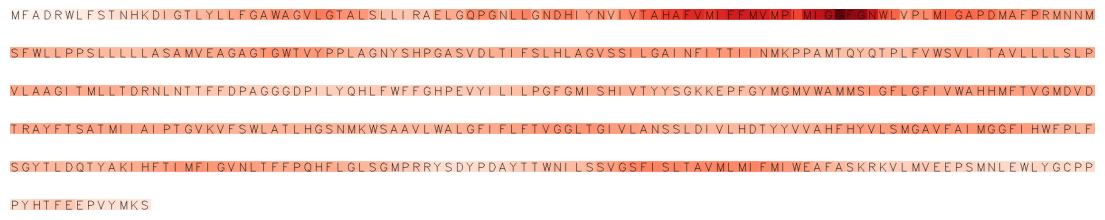

In [9]:
img_bgr = cv2.imread('demo_interpretation/interpretation_result.slice.png', cv2.IMREAD_UNCHANGED)

if img_bgr.shape[2] == 4:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGRA2RGBA)
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()